<a href="https://colab.research.google.com/github/neurostatslab/error-in-variables-garon-2026/blob/main/demo_notebooks/004_gridcell_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!wget -O /content/dataset.zip "https://zenodo.org/records/6200517/files/waaga_agmon_et_al_2022_neuron_dataset.zip?download=1"
!unzip -q /content/dataset.zip -d /content/waaga_agmon_2022/
!find /content/waaga_agmon_2022/python_format/ -maxdepth 2

--2026-07-17 19:00:12--  https://zenodo.org/records/6200517/files/waaga_agmon_et_al_2022_neuron_dataset.zip?download=1
Resolving zenodo.org (zenodo.org)... 137.138.153.219, 188.185.48.75, 188.184.98.114, ...
Connecting to zenodo.org (zenodo.org)|137.138.153.219|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 286358097 (273M) [application/octet-stream]
Saving to: ‘/content/dataset.zip’

/content/dataset.zi 100%[===================>] 273.09M  3.13MB/s    in 67s     

2026-07-17 19:01:20 (4.06 MB/s) - ‘/content/dataset.zip’ saved [286358097/286358097]

/content/waaga_agmon_2022/python_format/
/content/waaga_agmon_2022/python_format/moserlab_waaga_26018_2019-12-10_15-25-47_v1.npy
/content/waaga_agmon_2022/python_format/readme.md
/content/waaga_agmon_2022/python_format/moserlab_waaga_25843_2019-09-13_22-54-22_v1.npy
/content/waaga_agmon_2022/python_format/moserlab_waaga_26718_2020-09-16_17-23-51_v1.npy
/content/waaga_agmon_2022/python_format/moserlab_waaga_26820_20

In [2]:
%%capture
!git clone https://github.com/neurostatslab/error-in-variables-garon-2026.git
import sys
sys.path.append('error-in-variables-garon-2026/')

!pip install -q "jax[cuda12]==0.6.0" "jaxlib==0.6.0" optax tensorflow-probability
!pip install pynapple

import jax
from jax import config
config.update("jax_enable_x64", True)

import jax.numpy as jnp
import optax
from tensorflow_probability.substrates import jax as tfp
tfd = tfp.distributions

import time
import matplotlib.pyplot as plt
import numpy as np
import loader
import utils
import noise_models
from core import DynamicEIV, EIV



/usr/local/lib/python3.12/dist-packages/pynapple/core/ts_group.py:318: FutureWarning: initializing metadata with variable keyword arguments may be unsupported in a future version of Pynapple. Instead, initialize using the metadata argument.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/pynapple/process/tuning_curves.py:634: FutureWarning: compute_2d_tuning_curves is deprecated and will be removed in a future version;use compute_tuning_curves instead.
  return func(**kwargs)


Num steps:  128840  Num neurons:  205


Text(0.5, 1.0, 'dark position')

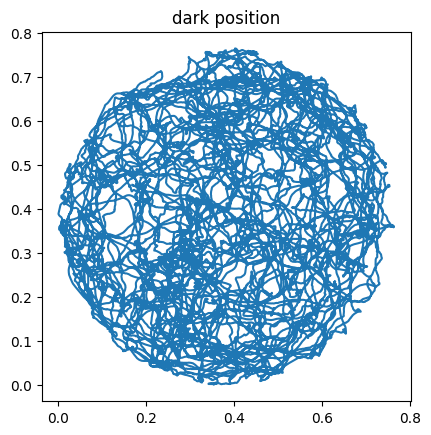

In [9]:

filepath = "/content/waaga_agmon_2022/python_format/moserlab_waaga_26018_2019-12-10_15-25-47_v1.npy"
epoch = "dark"


### Load Dataset
bin_size = .025
min_cm_per_sec = 5

data = loader.BurakGridCells(filepath, scale=.8)


sp_inds = data.spikes.keys()
y_and_s = data.load_data_by_index(sp_inds, epoch, bin_size)

num_steps, num_neurons = y_and_s[0].shape
print("Num steps: ", num_steps, " Num neurons: ", num_neurons)
num_dims = y_and_s[1].shape[1]

### Process tuning curves
tuning = data.get_tuning()
tuning_curves = np.zeros((20,num_neurons, 20))

mask_nan_inds = jnp.where(jnp.isnan(tuning[next(iter(tuning))]))

for num, i in enumerate(tuning.keys()):
    tuning_curves[:,num,:] = tuning[i]

tuning_curves = jnp.nan_to_num(jnp.array(tuning_curves), nan=0.0)


### Filter slow moving timepoints
diffs = jnp.diff(y_and_s[1], axis=0)
dists = jnp.linalg.norm(diffs, axis=1)
speed = np.abs(dists)
speed_thresh = (min_cm_per_sec/(165/.8))*bin_size
incl = jnp.where(speed>speed_thresh)

y_and_s = tuple((jnp.squeeze(y_and_s[0][incl, :]), jnp.squeeze(y_and_s[1][incl,:])))
y_and_s = tuple((y_and_s[0][:, :], y_and_s[1][:,:]))

plt.figure()
plt.plot(y_and_s[1][:,0], y_and_s[1][:,1])
plt.gca().set_aspect('equal')
plt.title(epoch + " position")



 ####  gpu ( NVIDIA A100-SXM4-80GB )
| Method | Datascale | Small (N= 205 T= 128840
|-----|------------------------------------------:|
| EIV |  7.473478812999929  secs


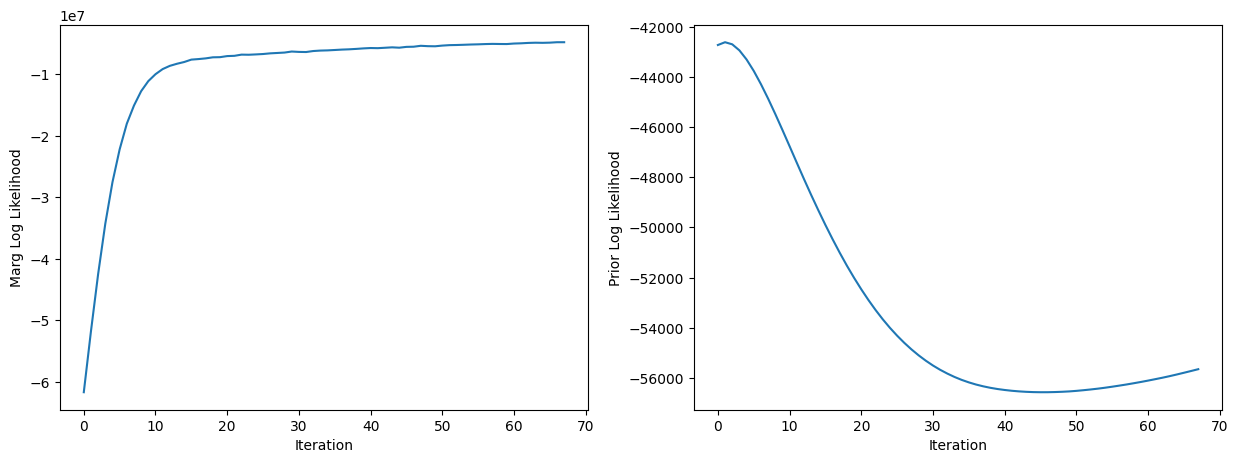

In [15]:
# Construct Model
model = EIV(len_scale = .12,
            out_scale = 30.,
            kappa = 5000.,
            num_dims=num_dims,
            num_neurons=num_neurons)


INIT_KEY = jax.random.PRNGKey(11)
OPT_KEY = jax.random.PRNGKey(123)

# Adjust run params, set up minibatching
opt_params = {
        "opt_key": OPT_KEY,
        "init_key": INIT_KEY,
        "tol_loss":1e-3,
        "n_iters":500,
        "lr":1e-1
    }

start_time = time.perf_counter()

model.fit(y_and_s, "adam", opt_params)
jax.block_until_ready(model.params_)

end_time = time.perf_counter()

print("\n\n #### " , jax.devices()[0].platform, "(", jax.devices()[0].device_kind,")")
print("| Method | Datascale | Small (N=", num_neurons, "T=",num_steps)
print("|-----|------------------------------------------:|")
print("| EIV | ", str(end_time - start_time), " secs")

utils.plot_objhist(model)
init_params = model.params_


batch_time_series: dropping last 1817 timestep(s) (t=55817 not divisible by window_size=3000); kept 54000/55817 samples across 18 batches.
batch_time_series: dropping last 1817 timestep(s) (t=55817 not divisible by window_size=3000); kept 54000/55817 samples across 18 batches.


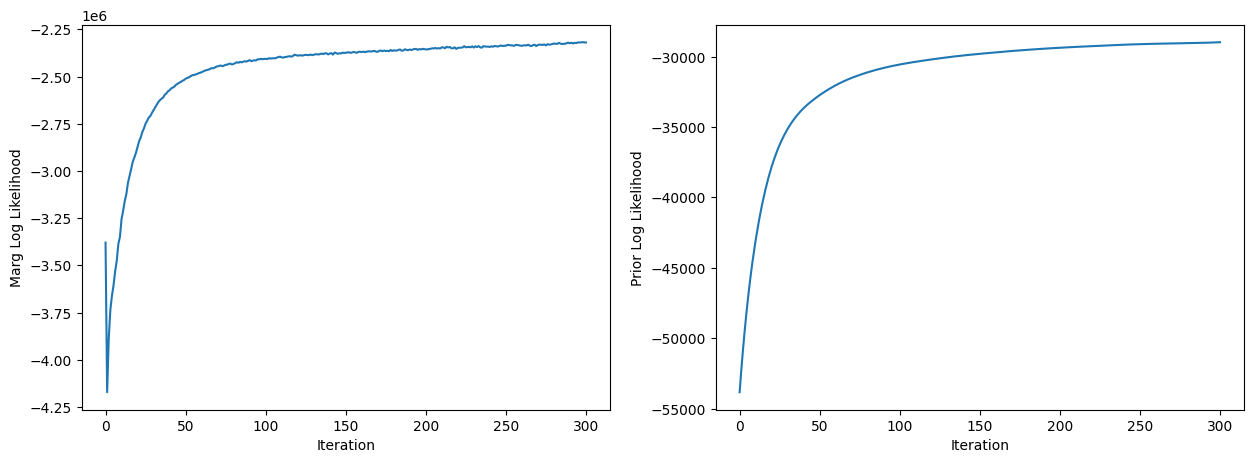

array([<Axes: xlabel='Iteration', ylabel='Marg Log Likelihood'>,
       <Axes: xlabel='Iteration', ylabel='Prior Log Likelihood'>],
      dtype=object)

In [16]:
# Construct Model
model = DynamicEIV(len_scale = .12,
            out_scale = 50.,
            kappa = 5.,
            num_dims=num_dims,
            num_neurons=num_neurons,
            proposal_concentration=6,
            proposal_noise = noise_models.ConcentratedDiscDistribution_resample,
            num_samples = 100)

# Adjust run params, set up minibatching
opt_params = {
        "init_params":init_params,
        "opt_key": OPT_KEY,
        "init_key": INIT_KEY,
        "n_iters":300,
        "tol_loss":1e-5,
        "batch_size":3000,
        "lr": 1e-1
    }


model.fit(y_and_s, "adam", opt_params)

utils.plot_objhist(model)

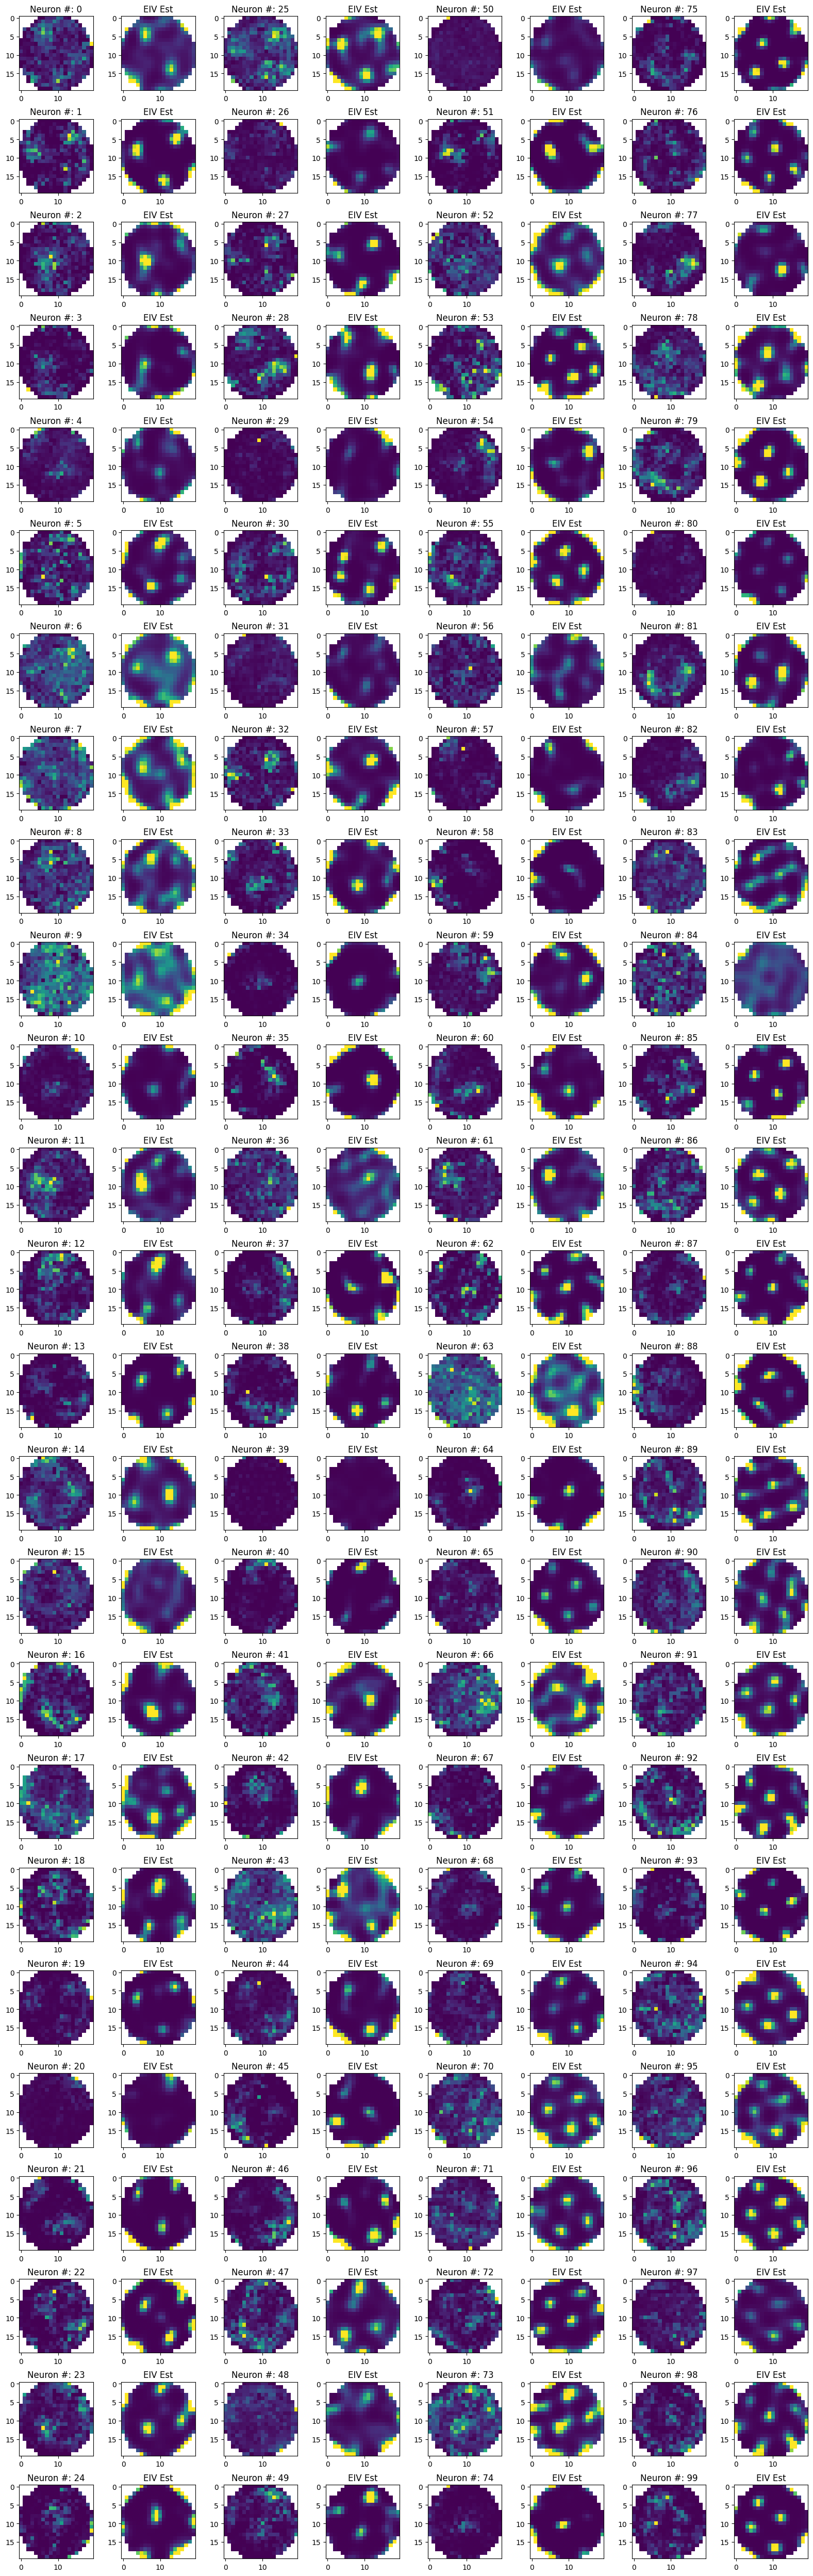

In [17]:
utils.plot_real_tuning_2d(model, tuning_curves, nan_mask=mask_nan_inds);